This script will make use of the newer DINOv3 since the original DINOv2 had great performance on the test set, so let us see if it can be further improved (It should be noted here that the image size has been increased to 518x518 due to that is what the creators mentionend as the best option when using this model): https://github.com/facebookresearch/dinov3

The first part of the code should be run on the CPU (dataset loading) before switching to the A100 for model training

Prerequisits

In [ ]:
!pip install -q pandas numpy

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Libraries

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np

Configuration

In [ ]:
DATASET_DIR = Path("/content/drive/MyDrive/Speciale/dataset/nutrition5k_compactV3")
METADATA_CSV = Path("/content/drive/MyDrive/Speciale/dataset/prepared_overhead_rgb_dataset/dish_carb_split_metadata.csv")

OUTPUT_DIR = Path("/content/drive/MyDrive/Speciale/Models/Model_3_V4_DINOv3_RGB_only")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PREP_DIR = OUTPUT_DIR / "prep_files"
PREP_DIR.mkdir(parents=True, exist_ok=True)

Dataset loading and splitting

In [ ]:
df = pd.read_csv(METADATA_CSV)

print(df.head())
print(df["split"].value_counts())
print("Total rows:", len(df))

           dish_id  total_carb split source_cafe
0  dish_1556575327      10.618  test       cafe1
1  dish_1557861216       0.000  test       cafe1
2  dish_1557862345       0.000  test       cafe1
3  dish_1557862696       3.850  test       cafe1
4  dish_1557862738       0.000  test       cafe1
split
train    2421
test      507
val       334
Name: count, dtype: int64
Total rows: 3262


In [ ]:
df["rgb_path"] = df["dish_id"].apply(
    lambda d: str(DATASET_DIR / str(d) / "overhead" / "rgb.png")
)

df["rgb_exists"] = df["rgb_path"].apply(lambda p: Path(p).exists())

print("Missing RGB images:", (~df["rgb_exists"]).sum())

Missing RGB images: 0


In [ ]:
def file_size_or_minus1(path_str):
    p = Path(path_str)
    try:
        return p.stat().st_size
    except:
        return -1

df["rgb_size"] = df["rgb_path"].apply(file_size_or_minus1)

print("Empty RGB files:", (df["rgb_size"] <= 0).sum())

df = df[
    (df["rgb_exists"]) &
    (df["rgb_size"] > 0)
].copy()

print("\nRemaining samples after filtering:")
print(df["split"].value_counts())
print("Total remaining:", len(df))

Empty RGB files: 0

Remaining samples after filtering:
split
train    2421
test      507
val       334
Name: count, dtype: int64
Total remaining: 3262


In [ ]:
train_df = df[df["split"] == "train"].copy().reset_index(drop=True)
val_df   = df[df["split"] == "val"].copy().reset_index(drop=True)
test_df  = df[df["split"] == "test"].copy().reset_index(drop=True)

print("Train:", len(train_df))
print("Val:  ", len(val_df))
print("Test: ", len(test_df))

Train: 2421
Val:   334
Test:  507


In [ ]:
train_csv = PREP_DIR / "train_rgb_only.csv"
val_csv   = PREP_DIR / "val_rgb_only.csv"
test_csv  = PREP_DIR / "test_rgb_only.csv"
full_csv  = PREP_DIR / "full_filtered_rgb_only.csv"

train_df.to_csv(train_csv, index=False)
val_df.to_csv(val_csv, index=False)
test_df.to_csv(test_csv, index=False)
df.to_csv(full_csv, index=False)

print("Saved:")
print(train_csv)
print(val_csv)
print(test_csv)
print(full_csv)

Saved:
/content/drive/MyDrive/Speciale/Models/Model_3_V4_DINOv3_RGB_only/prep_files/train_rgb_only.csv
/content/drive/MyDrive/Speciale/Models/Model_3_V4_DINOv3_RGB_only/prep_files/val_rgb_only.csv
/content/drive/MyDrive/Speciale/Models/Model_3_V4_DINOv3_RGB_only/prep_files/test_rgb_only.csv
/content/drive/MyDrive/Speciale/Models/Model_3_V4_DINOv3_RGB_only/prep_files/full_filtered_rgb_only.csv


Switch to GPU

Prerequisits

In [ ]:
!pip install -q keras-hub huggingface_hub

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import keras_hub

from huggingface_hub import notebook_login, HfApi

In [ ]:
notebook_login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Configuration

In [ ]:
IMG_HEIGHT = 518
IMG_WIDTH  = 518
BATCH_SIZE = 16
AUTOTUNE   = tf.data.AUTOTUNE

STAGE1_EPOCHS = 100
STAGE2_EPOCHS = 200

STAGE1_LR = 2e-4
STAGE2_LR = 5e-6

# ---------------------------------------------------------
# Possible DINO options starting with dinov2_large
# DINOv2:
#   "dinov2_small"
#   "dinov2_base"
#   "dinov2_large"
#
# DINOv3:
#   "dinov3_vit_small_lvd1689m"
#   "dinov3_vit_small_plus_lvd1689m"
#   "dinov3_vit_base_lvd1689m"
#   "dinov3_vit_large_lvd1689m"
# ---------------------------------------------------------
BACKBONE_PRESET = "dinov3_vit_base_lvd1689m"

OUTPUT_DIR = Path("/content/drive/MyDrive/Speciale/Models/Model_3_V4_DINOv3_RGB_only")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PREP_DIR = OUTPUT_DIR / "prep_files"

train_csv = PREP_DIR / "train_rgb_only.csv"
val_csv   = PREP_DIR / "val_rgb_only.csv"
test_csv  = PREP_DIR / "test_rgb_only.csv"

Loading dataset paths and then later the images

In [ ]:
train_df = pd.read_csv(train_csv)
val_df   = pd.read_csv(val_csv)
test_df  = pd.read_csv(test_csv)

print("Train:", len(train_df))
print("Val:  ", len(val_df))
print("Test: ", len(test_df))

display(train_df.head())

Train: 2421
Val:   334
Test:  507


,dish_id,total_carb,split,source_cafe,rgb_path,rgb_exists,rgb_size
0,dish_1556572657,2.268,train,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,412129
1,dish_1556573514,1.219,train,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,432908
2,dish_1556575014,3.906,train,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,409854
3,dish_1556575083,5.760,train,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,396942
4,dish_1556575124,0.952,train,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,404314


In [ ]:
def load_rgb_image(rgb_path):
    image = tf.io.read_file(rgb_path)
    image = tf.image.decode_png(image, channels=3)

    image = tf.image.resize_with_pad(
        image,
        target_height=IMG_HEIGHT,
        target_width=IMG_WIDTH,
        method=tf.image.ResizeMethod.BILINEAR,
        antialias=True
    )

    image = tf.cast(image, tf.float32)
    return image


def load_rgb_and_label(rgb_path, label):
    rgb = load_rgb_image(rgb_path)
    label = tf.cast(label, tf.float32)
    return {"rgb_input": rgb}, label


def make_dataset(dataframe, batch_size=16, shuffle=False):
    rgb_paths = dataframe["rgb_path"].values
    labels = dataframe["total_carb"].values.astype("float32")

    ds = tf.data.Dataset.from_tensor_slices((rgb_paths, labels))

    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=42)

    ds = ds.map(load_rgb_and_label, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(AUTOTUNE)

    return ds

In [ ]:
train_dataset = make_dataset(train_df, batch_size=BATCH_SIZE, shuffle=True)
validation_dataset = make_dataset(val_df, batch_size=BATCH_SIZE, shuffle=False)
test_dataset = make_dataset(test_df, batch_size=BATCH_SIZE, shuffle=False)

for batch_inputs, batch_labels in train_dataset.take(1):
    print("RGB batch shape:", batch_inputs["rgb_input"].shape)
    print("Labels shape:   ", batch_labels.shape)

RGB batch shape: (16, 518, 518, 3)
Labels shape:    (16,)


Showing an image in the dataset

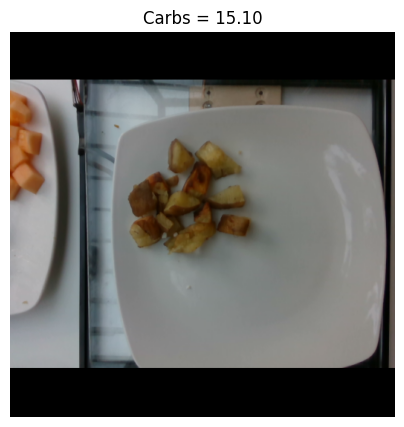

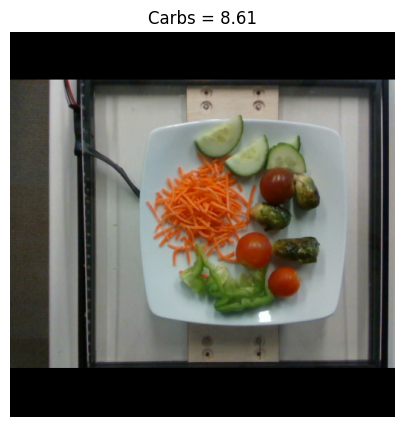

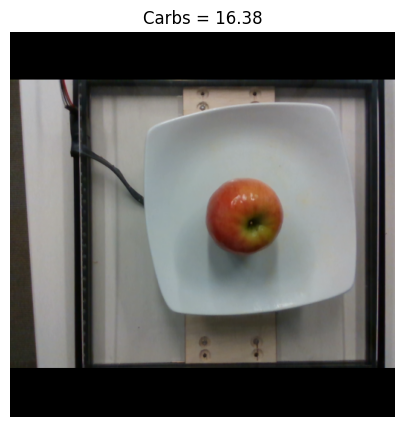

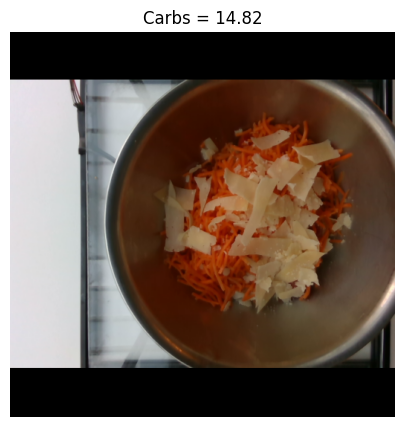

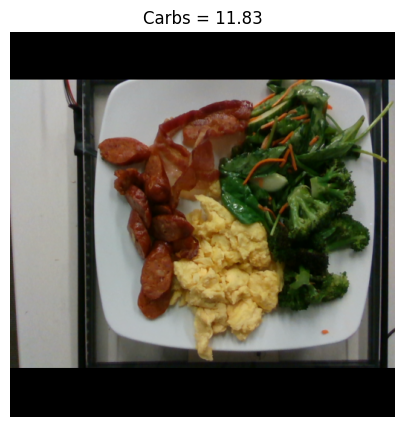

In [ ]:
for batch_inputs, batch_labels in train_dataset.take(5):
    sample_img = batch_inputs["rgb_input"][0].numpy().astype("uint8")
    sample_label = batch_labels[0].numpy()

    plt.figure(figsize=(5, 5))
    plt.imshow(sample_img)
    plt.title(f"Carbs = {sample_label:.2f}")
    plt.axis("off")
    plt.show()

Loading ViT backbone + image converter

In [ ]:
image_converter = keras_hub.layers.ImageConverter.from_preset(
    BACKBONE_PRESET,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
)

backbone = keras_hub.models.Backbone.from_preset(
    BACKBONE_PRESET,
    image_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
)

backbone.trainable = False

print("Using preset:", BACKBONE_PRESET)
print("Image size:", (IMG_HEIGHT, IMG_WIDTH))

Using preset: dinov3_vit_base_lvd1689m
Image size: (518, 518)


In [ ]:
def extract_backbone_tensor(x):
    if isinstance(x, dict):
        preferred_keys = [
            "sequence_output",
            "pooled_output",
            "encoder_output",
            "token_embeddings",
            "hidden_states"
        ]
        for key in preferred_keys:
            if key in x:
                return x[key]
        return list(x.values())[0]
    return x

Model architecture

In [ ]:
rgb_input = keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3), name="rgb_input")

x = image_converter(rgb_input)
x = backbone(x)
x = extract_backbone_tensor(x)

if len(x.shape) == 3:
    x = layers.LayerNormalization()(x)
    x = layers.GlobalAveragePooling1D(name="token_pool")(x)
else:
    x = layers.LayerNormalization()(x)
    x = layers.Flatten()(x)

x = layers.Dropout(0.3)(x)
x = layers.Dense(256, activation="relu", name="dense_256")(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(64, activation="relu", name="dense_64")(x)
output = layers.Dense(1, activation="linear", name="carb_output")(x)

model = keras.Model(
    inputs={"rgb_input": rgb_input},
    outputs=output,
    name="rgb_only_dino_vit_regressor"
)

model.summary()

Model: "rgb_only_dino_vit_regressor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rgb_input (InputLayer)          │ (None, 518, 518, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dinov3_image_converter          │ (None, 518, 518, 3)    │             0 │
│ (DINOV3ImageConverter)          │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dinov3_backbone                 │ (None, 1029, 768)      │    85,660,416 │
│ (DINOV3Backbone)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_2           │ (None, 1029, 768)      │         1,536 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_pool                      │ (None, 768)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ carb_output (Dense)             │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85,875,329 (327.59 MB)

 Trainable params: 214,913 (839.50 KB)

 Non-trainable params: 85,660,416 (326.77 MB)

Stage 1 (here only a regression head will be trained)

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=STAGE1_LR),
    loss="mse",
    metrics=[
        keras.metrics.MeanAbsoluteError(name="mae"),
        keras.metrics.MeanSquaredError(name="mse")
    ],
    jit_compile=False
)

In [ ]:
stage1_best_path = OUTPUT_DIR / "best_model_stage1.weights.h5"

stage1_callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=str(stage1_best_path),
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True,
        mode="min",
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=50,
        mode="min",
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=35,
        min_lr=1e-6,
        mode="min",
        verbose=1
    )
]

In [ ]:
history_stage1 = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=STAGE1_EPOCHS,
    callbacks=stage1_callbacks
)

Epoch 1/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 952ms/step - loss: 665.6810 - mae: 15.2829 - mse: 665.6810
Epoch 1: val_loss improved from None to 190.46664, saving model to /content/drive/MyDrive/Speciale/Models/Model_3_V4_DINOv3_RGB_only/best_model_stage1.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/Speciale/Models/Model_3_V4_DINOv3_RGB_only/best_model_stage1.weights.h5
152/152 ━━━━━━━━━━━━━━━━━━━━ 191s 1s/step - loss: 585.9506 - mae: 13.4112 - mse: 585.9506 - val_loss: 190.4666 - val_mae: 10.9114 - val_mse: 190.4666 - learning_rate: 2.0000e-04
Epoch 2/100
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step - loss: 212.5417 - mae: 10.8075 - mse: 212.5417
Epoch 2: val_loss improved from 190.46664 to 154.32283, saving model to /content/drive/MyDrive/Speciale/Models/Model_3_V4_DINOv3_RGB_only/best_model_stage1.weights.h5

Epoch 2: finished saving model to /content/drive/MyDrive/Speciale/Models/Model_3_V4_DINOv3_RGB_only/best_model_stage1.weights.h5
152/152 ━━━━━━━━━━━━━━━━━━━

Evaluating stage 1 on test set

In [ ]:
model.load_weights(str(stage1_best_path))

stage1_test_results = model.evaluate(test_dataset, return_dict=True, verbose=1)

print("Stage 1 test results:")
for k, v in stage1_test_results.items():
    print(f"{k}: {v:.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - loss: 85.3821 - mae: 6.1269 - mse: 85.3821
Stage 1 test results:
loss: 85.3821
mae: 6.1269
mse: 85.3821


Stage 2 (last 30% of the backbone ViT will be unfrozen)

In [ ]:
model.load_weights(str(stage1_best_path))

backbone.trainable = True

num_layers = len(backbone.layers)
freeze_until = int(num_layers * 0.70)

for i, layer in enumerate(backbone.layers):
    layer.trainable = (i >= freeze_until)

print(f"Total backbone layers: {num_layers}")
print(f"Frozen layers:         {freeze_until}")
print(f"Trainable layers:      {num_layers - freeze_until}")

trainable_count = 0
frozen_count = 0
for layer in backbone.layers:
    if layer.trainable:
        trainable_count += 1
    else:
        frozen_count += 1

print("Backbone trainable layers:", trainable_count)
print("Backbone frozen layers:   ", frozen_count)

Total backbone layers: 5
Frozen layers:         3
Trainable layers:      2
Backbone trainable layers: 2
Backbone frozen layers:    3


In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=STAGE2_LR),
    loss="mse",
    metrics=[
        keras.metrics.MeanAbsoluteError(name="mae"),
        keras.metrics.MeanSquaredError(name="mse")
    ],
    jit_compile=False
)

In [ ]:
stage2_best_path = OUTPUT_DIR / "best_model_stage2.weights.h5"

stage2_callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=str(stage2_best_path),
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True,
        mode="min",
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=100,
        mode="min",
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=75,
        min_lr=1e-7,
        mode="min",
        verbose=1
    )
]

In [ ]:
history_stage2 = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=STAGE2_EPOCHS,
    callbacks=stage2_callbacks
)

Epoch 1/200
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 620ms/step - loss: 100.4311 - mae: 5.7535 - mse: 100.4311
Epoch 1: val_loss improved from None to 181.39267, saving model to /content/drive/MyDrive/Speciale/Models/Model_3_V4_DINOv3_RGB_only/best_model_stage2.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/Speciale/Models/Model_3_V4_DINOv3_RGB_only/best_model_stage2.weights.h5
152/152 ━━━━━━━━━━━━━━━━━━━━ 142s 694ms/step - loss: 336.5732 - mae: 6.1826 - mse: 336.5732 - val_loss: 181.3927 - val_mae: 8.7604 - val_mse: 181.3927 - learning_rate: 5.0000e-06
Epoch 2/200
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 630ms/step - loss: 160.6778 - mae: 6.2955 - mse: 160.6778
Epoch 2: val_loss improved from 181.39267 to 57.21047, saving model to /content/drive/MyDrive/Speciale/Models/Model_3_V4_DINOv3_RGB_only/best_model_stage2.weights.h5

Epoch 2: finished saving model to /content/drive/MyDrive/Speciale/Models/Model_3_V4_DINOv3_RGB_only/best_model_stage2.weights.h5
152/152 ━━━━━━━━━━━━━━━━━━━━ 

Evaluating stage 2 on test set

In [ ]:
model.load_weights(str(stage2_best_path))

stage2_test_results = model.evaluate(test_dataset, return_dict=True, verbose=1)

print("Stage 2 test results:")
for k, v in stage2_test_results.items():
    print(f"{k}: {v:.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 241ms/step - loss: 57.4370 - mae: 5.2939 - mse: 57.4370
Stage 2 test results:
loss: 57.4370
mae: 5.2939
mse: 57.4370


Plotting training and validation curves

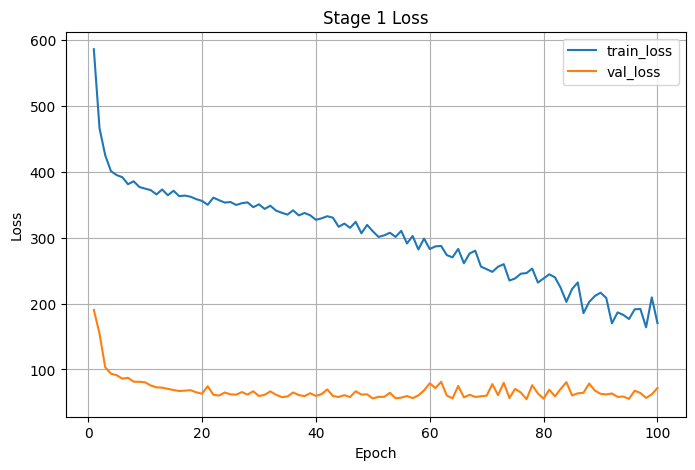

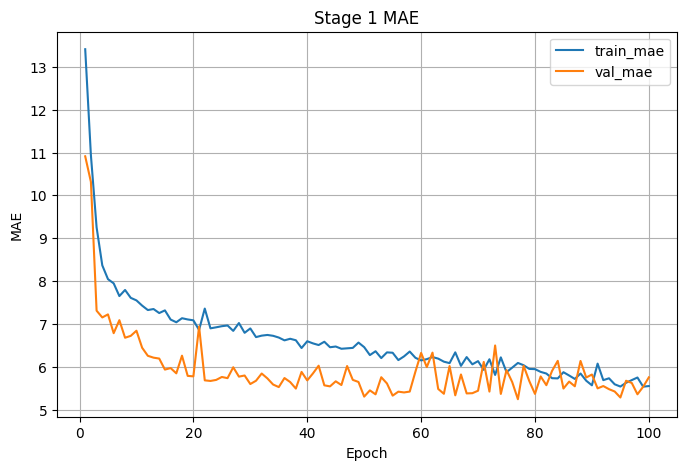

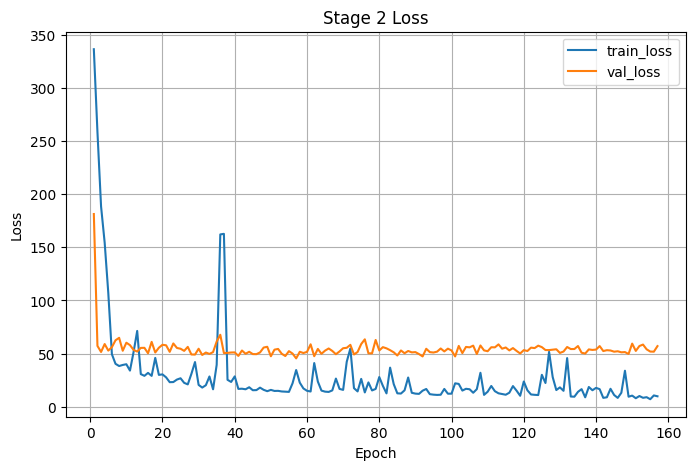

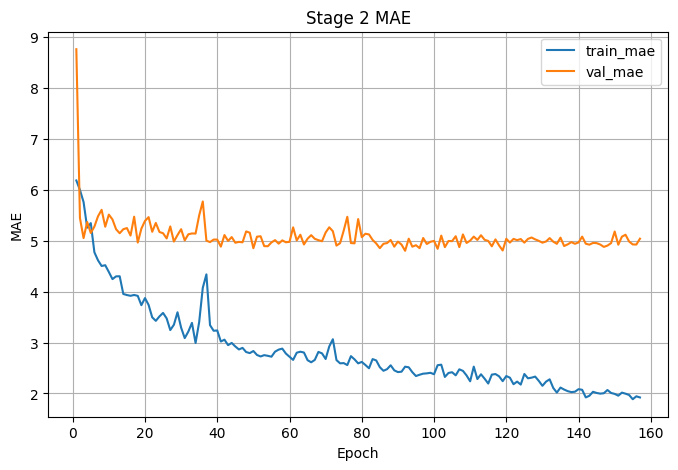

In [ ]:
def plot_history(history, title_prefix=""):
    hist = history.history
    epochs = range(1, len(hist["loss"]) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, hist["loss"], label="train_loss")
    plt.plot(epochs, hist["val_loss"], label="val_loss")
    plt.title(f"{title_prefix} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, hist["mae"], label="train_mae")
    plt.plot(epochs, hist["val_mae"], label="val_mae")
    plt.title(f"{title_prefix} MAE")
    plt.xlabel("Epoch")
    plt.ylabel("MAE")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_history(history_stage1, "Stage 1")
plot_history(history_stage2, "Stage 2")

Comparing stage 1 vs stage 2

In [ ]:
comparison_df = pd.DataFrame([
    {
        "stage": "stage_1",
        "test_loss": stage1_test_results.get("loss"),
        "test_mae": stage1_test_results.get("mae"),
        "test_mse": stage1_test_results.get("mse"),
    },
    {
        "stage": "stage_2",
        "test_loss": stage2_test_results.get("loss"),
        "test_mae": stage2_test_results.get("mae"),
        "test_mse": stage2_test_results.get("mse"),
    }
])

display(comparison_df)
comparison_df.to_csv(OUTPUT_DIR / "stage_test_comparison.csv", index=False)

,stage,test_loss,test_mae,test_mse
0,stage_1,85.382072,6.126912,85.382072
1,stage_2,57.436954,5.293879,57.436954


Saving test predictions

In [ ]:
model.load_weights(str(stage2_best_path))

test_eval_df = test_df.copy().reset_index(drop=True)

preds = model.predict(test_dataset, verbose=1).reshape(-1)

test_eval_df["prediction"] = preds
test_eval_df["abs_error"] = np.abs(test_eval_df["total_carb"] - test_eval_df["prediction"])
test_eval_df["signed_error"] = test_eval_df["prediction"] - test_eval_df["total_carb"]

pred_csv = OUTPUT_DIR / "test_predictions_stage2.csv"
test_eval_df.to_csv(pred_csv, index=False)

print("Saved:", pred_csv)
display(test_eval_df.head())

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'pixel_values': 'pixel_values'}
Received: inputs=Tensor(shape=(16, 518, 518, 3))
  warnings.warn(msg)


31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'pixel_values': 'pixel_values'}
Received: inputs=Tensor(shape=(None, 518, 518, 3))
  warnings.warn(msg)


32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 329ms/step
Saved: /content/drive/MyDrive/Speciale/Models/Model_3_V4_DINOv3_RGB_only/test_predictions_stage2.csv


,dish_id,total_carb,split,source_cafe,rgb_path,rgb_exists,rgb_size,prediction,abs_error,signed_error
0,dish_1556575327,10.618,test,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,548259,13.879735,3.261735,3.261735
1,dish_1557861216,0.000,test,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,353804,4.431726,4.431726,4.431726
2,dish_1557862345,0.000,test,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,407501,2.249640,2.249640,2.249640
3,dish_1557862696,3.850,test,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,391780,2.714418,1.135582,-1.135582
4,dish_1557862738,0.000,test,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,412017,3.446981,3.446981,3.446981


Top 10 best and worst dishes

In [ ]:
best_10 = test_eval_df.sort_values("abs_error", ascending=True).head(10)
worst_10 = test_eval_df.sort_values("abs_error", ascending=False).head(10)

print("Top 10 best predictions:")
display(best_10[["dish_id", "total_carb", "prediction", "abs_error", "signed_error"]])

print("Top 10 worst predictions:")
display(worst_10[["dish_id", "total_carb", "prediction", "abs_error", "signed_error"]])

best_10.to_csv(OUTPUT_DIR / "top10_best_predictions_stage2.csv", index=False)
worst_10.to_csv(OUTPUT_DIR / "top10_worst_predictions_stage2.csv", index=False)

Top 10 best predictions:


,dish_id,total_carb,prediction,abs_error,signed_error
396,dish_1565035802,14.785000,14.774191,0.010809,-0.010809
60,dish_1558461692,9.080000,9.063752,0.016248,-0.016248
28,dish_1558110335,0.098000,0.133309,0.035309,0.035309
107,dish_1558722171,4.850000,4.808546,0.041454,-0.041454
400,dish_1565117463,53.588001,53.543839,0.044162,-0.044162
281,dish_1562776428,5.852568,5.786241,0.066327,-0.066327
199,dish_1561405356,7.496847,7.415636,0.081211,-0.081211
54,dish_1558376801,0.795000,0.898922,0.103922,0.103922
20,dish_1558030383,0.364000,0.473114,0.109114,0.109114
95,dish_1558717604,19.879999,19.759716,0.120283,-0.120283


Top 10 worst predictions:


,dish_id,total_carb,prediction,abs_error,signed_error
454,dish_1566501594,54.281998,17.816755,36.465243,-36.465243
178,dish_1560801020,61.690983,27.304068,34.386915,-34.386915
179,dish_1560801041,63.245892,29.920948,33.324944,-33.324944
177,dish_1560800988,61.249092,28.929108,32.319984,-32.319984
325,dish_1563566909,46.750000,19.792320,26.957680,-26.957680
313,dish_1563478751,54.133282,29.262482,24.870800,-24.870800
446,dish_1566328805,85.054001,60.732735,24.321266,-24.321266
150,dish_1560367980,47.243912,23.477623,23.766289,-23.766289
149,dish_1560367952,45.956913,22.278334,23.678579,-23.678579
506,dish_1568401302,69.864967,47.115582,22.749385,-22.749385


Saving final model

In [ ]:
model.load_weights(str(stage2_best_path))

final_keras_path = OUTPUT_DIR / "final_model.keras"
model.save(final_keras_path)

export_dir = OUTPUT_DIR / "saved_model_export"
model.export(export_dir)

print("Saved final .keras model to:", final_keras_path)
print("Saved exported model to:", export_dir)

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'pixel_values': 'pixel_values'}
Received: inputs=Tensor(shape=(None, 518, 518, 3))
  warnings.warn(msg)


Saved artifact at '/content/drive/MyDrive/Speciale/Models/Model_3_V4_DINOv3_RGB_only/saved_model_export'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): Dict[['rgb_input', TensorSpec(shape=(None, 518, 518, 3), dtype=tf.float32, name='rgb_input')]]
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  131924345545232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131924345548112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131924345547728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131924345543120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131924345542928: TensorSpec(shape=(16,), dtype=tf.float32, name=None)
  131924345548304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131924345546576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131924345546192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131924345546960: TensorSpec(shape=(), dtype=tf.resource, name=None